In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.naive_bayes import GaussianNB

In [3]:
data = pd.read_csv("/content/CASS_Spectrum_Dataset_10000_stronger_patterns.csv")
print(data.head())
print(data.describe())
print(data.info())

   PU_Signal_Strength  Frequency_Band    SNR_SU1    SNR_SU2    SNR_SU3  \
0          -64.929185            3500  13.134728   5.109027  15.677431   
1          -63.141397            5000  10.030155   7.536356  12.800551   
2          -68.254612            2400  12.619253   2.524408   8.005770   
3          -67.114017            5000   5.942732   9.704668  15.617976   
4          -56.524985            5000  10.573545  12.348475  11.840221   

   Cluster_ID  Cluster_Size    SNR_avg    SNR_max    SNR_min   SNR_std  \
0          26            16  11.307062  15.677431   5.109027  4.503929   
1           7            13  10.122354  12.800551   7.536356  2.150087   
2           4            15   7.716477  12.619253   2.524408  4.126277   
3          29             9  10.421792  15.617976   5.942732  3.982318   
4          24            12  11.587414  12.348475  10.573545  0.746337   

   Signal_cluster_ratio  Target  
0             -3.819364       1  
1             -4.510100       1  
2       

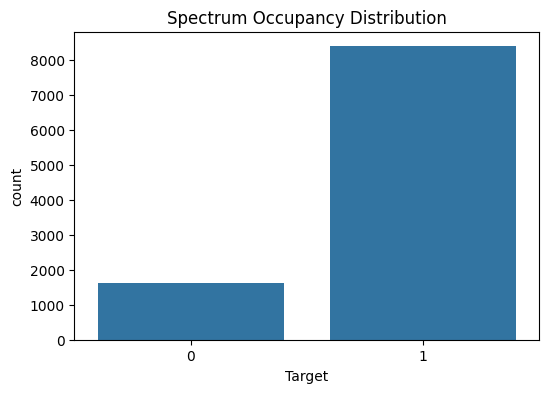

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x="Target",data=data)
plt.title("Spectrum Occupancy Distribution")
plt.show()

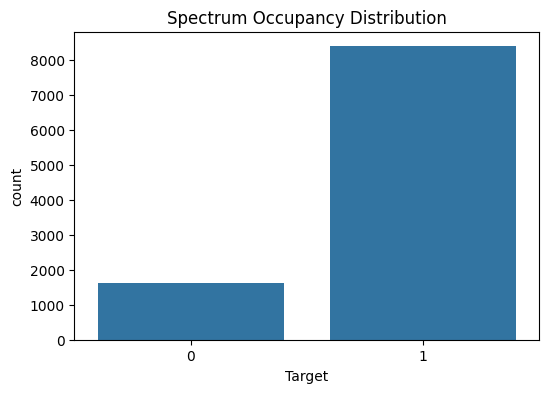

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="Target",data=data)
plt.title("Spectrum Occupancy Distribution")
plt.show()

In [6]:
X = data.drop("Target",axis=1)
y = data["Target"]

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [7]:
X_train,X_test,y_train,y_test = train_test_split(
X_scaled,y,test_size=0.2,random_state=42)

In [8]:
# ==========================================================
# HYPERPARAMETER TUNING FOR ALL MODELS
# ==========================================================

from sklearn.model_selection import GridSearchCV

tuned_models = {}

# ----------------------------------------------------------
# Logistic Regression
# ----------------------------------------------------------
log_params = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

log_grid = GridSearchCV(LogisticRegression(max_iter=1000), log_params, cv=3)
log_grid.fit(X_train, y_train)
tuned_models["Logistic Regression"] = log_grid.best_estimator_

# ----------------------------------------------------------
# KNN
# ----------------------------------------------------------
knn_params = {
    'n_neighbors': [3,5,7],
    'weights': ['uniform','distance']
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3)
knn_grid.fit(X_train, y_train)
tuned_models["KNN"] = knn_grid.best_estimator_

# ----------------------------------------------------------
# SVM
# ----------------------------------------------------------
svm_params = {
    'C': [0.1,1,10],
    'kernel': ['linear','rbf'],
    'gamma': ['scale','auto']
}

svm_grid = GridSearchCV(SVC(probability=True), svm_params, cv=3)
svm_grid.fit(X_train, y_train)
tuned_models["SVM"] = svm_grid.best_estimator_

# ----------------------------------------------------------
# Decision Tree
# ----------------------------------------------------------
dt_params = {
    'max_depth': [None,5,10],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(), dt_params, cv=3)
dt_grid.fit(X_train, y_train)
tuned_models["Decision Tree"] = dt_grid.best_estimator_

# ----------------------------------------------------------
# Random Forest
# ----------------------------------------------------------
rf_params = {
    'n_estimators': [50,100],
    'max_depth': [None,10],
    'max_features': ['sqrt','log2']
}

rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=3)
rf_grid.fit(X_train, y_train)
tuned_models["Random Forest"] = rf_grid.best_estimator_

# ----------------------------------------------------------
# Gradient Boosting
# ----------------------------------------------------------
gb_params = {
    'n_estimators': [50,100],
    'learning_rate': [0.01,0.1],
    'max_depth': [3,5]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(), gb_params, cv=3)
gb_grid.fit(X_train, y_train)
tuned_models["Gradient Boosting"] = gb_grid.best_estimator_

# ----------------------------------------------------------
# Naive Bayes
# ----------------------------------------------------------
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

nb_grid = GridSearchCV(GaussianNB(), nb_params, cv=3)
nb_grid.fit(X_train, y_train)
tuned_models["Naive Bayes"] = nb_grid.best_estimator_

# ==========================================================
# EVALUATE TUNED MODELS
# ==========================================================

print("\nTUNED MODEL ACCURACIES\n")

for name, model in tuned_models.items():

    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    print(name, ":", round(acc*100,2), "%")


TUNED MODEL ACCURACIES

Logistic Regression : 94.95 %
KNN : 93.55 %
SVM : 94.75 %
Decision Tree : 93.8 %
Random Forest : 93.95 %
Gradient Boosting : 94.6 %
Naive Bayes : 91.35 %


Logistic Regression Accuracy: 0.9495


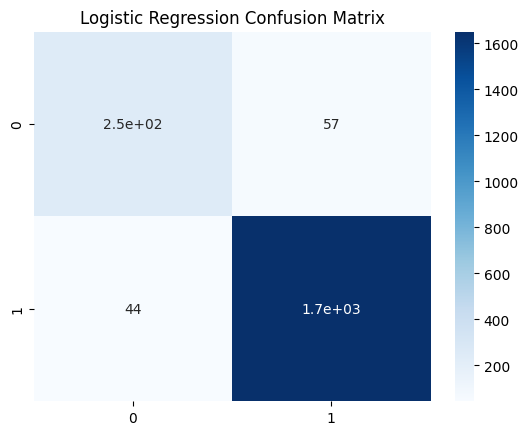

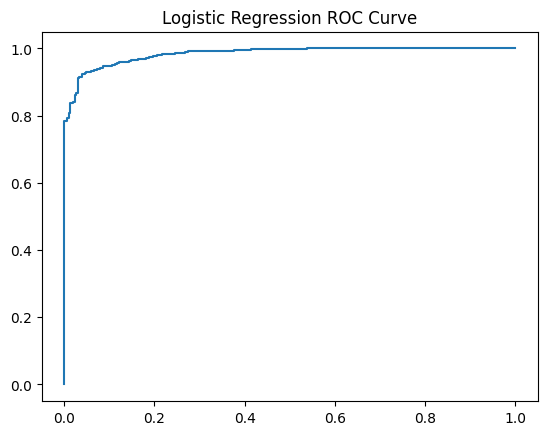

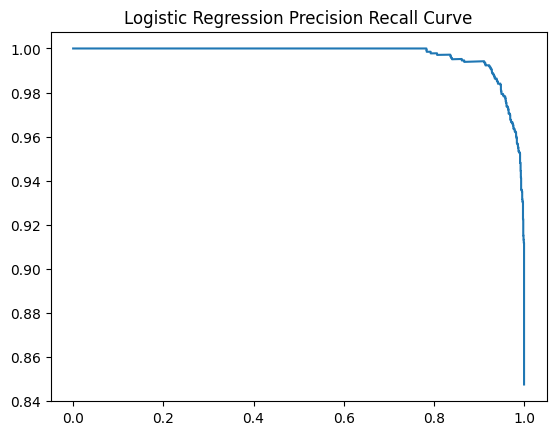

In [9]:
model = LogisticRegression()

model.fit(X_train,y_train)

pred = model.predict(X_test)

acc_lr = accuracy_score(y_test,pred)

print("Logistic Regression Accuracy:",acc_lr)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

prob = model.predict_proba(X_test)[:,1]

fpr_lr,tpr_lr,_ = roc_curve(y_test,prob)

plt.plot(fpr_lr,tpr_lr)
plt.title("Logistic Regression ROC Curve")
plt.show()

precision,recall,_ = precision_recall_curve(y_test,prob)

plt.plot(recall,precision)
plt.title("Logistic Regression Precision Recall Curve")
plt.show()

KNN Accuracy: 0.933


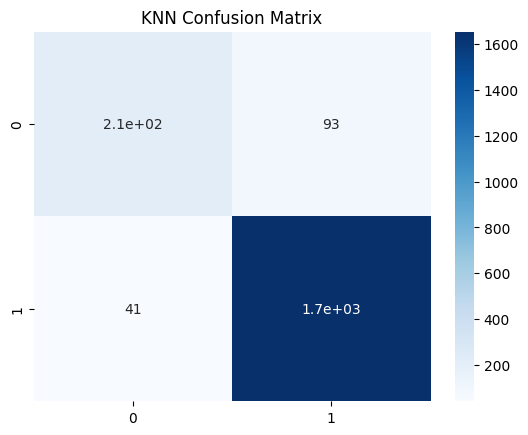

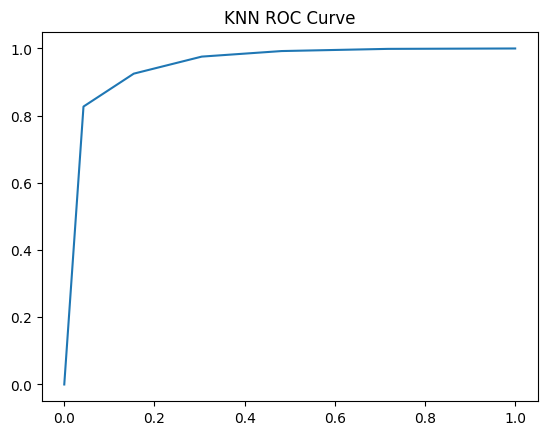

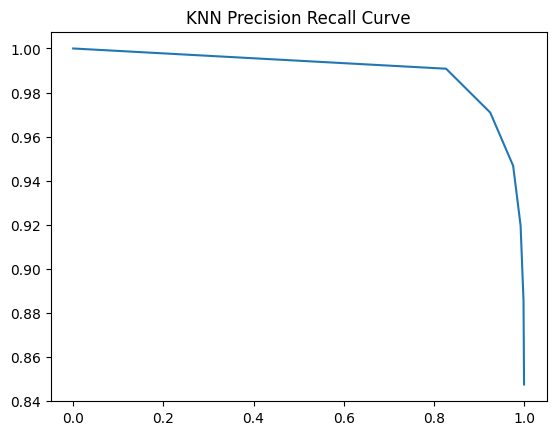

In [10]:
model = KNeighborsClassifier()

model.fit(X_train,y_train)

pred = model.predict(X_test)

acc_knn = accuracy_score(y_test,pred)

print("KNN Accuracy:",acc_knn)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.show()

prob = model.predict_proba(X_test)[:,1]

fpr_knn,tpr_knn,_ = roc_curve(y_test,prob)

plt.plot(fpr_knn,tpr_knn)
plt.title("KNN ROC Curve")
plt.show()

precision,recall,_ = precision_recall_curve(y_test,prob)

plt.plot(recall,precision)
plt.title("KNN Precision Recall Curve")
plt.show()


SVM Accuracy: 0.947


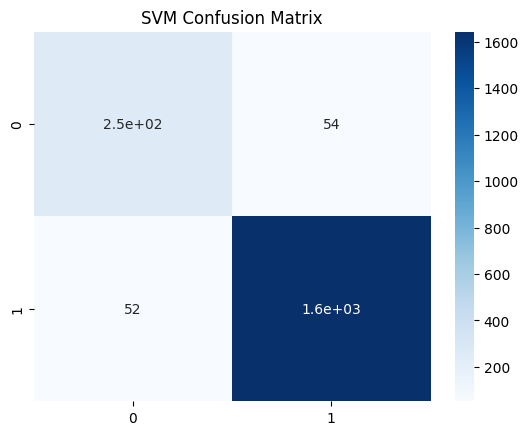

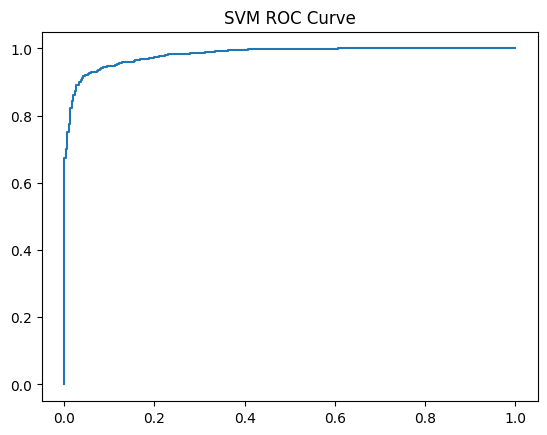

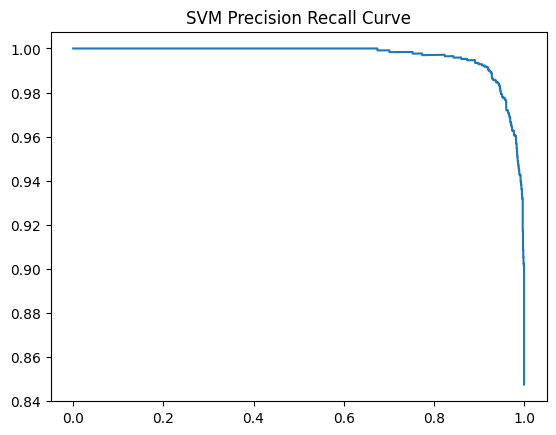

In [11]:
model = SVC(probability=True)

model.fit(X_train,y_train)

pred = model.predict(X_test)

acc_svm = accuracy_score(y_test,pred)

print("SVM Accuracy:",acc_svm)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()

prob = model.predict_proba(X_test)[:,1]

fpr_svm,tpr_svm,_ = roc_curve(y_test,prob)

plt.plot(fpr_svm,tpr_svm)
plt.title("SVM ROC Curve")
plt.show()

precision,recall,_ = precision_recall_curve(y_test,prob)

plt.plot(recall,precision)
plt.title("SVM Precision Recall Curve")
plt.show()

Decision Tree Accuracy: 0.9265


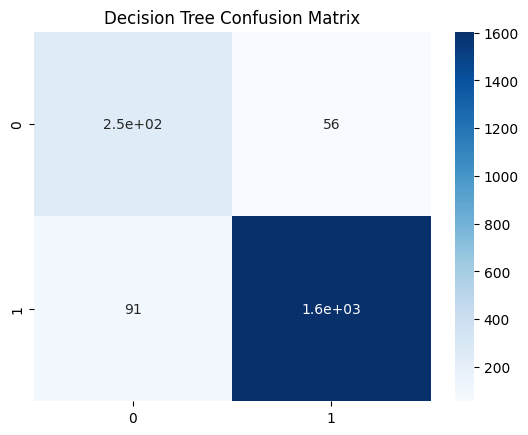

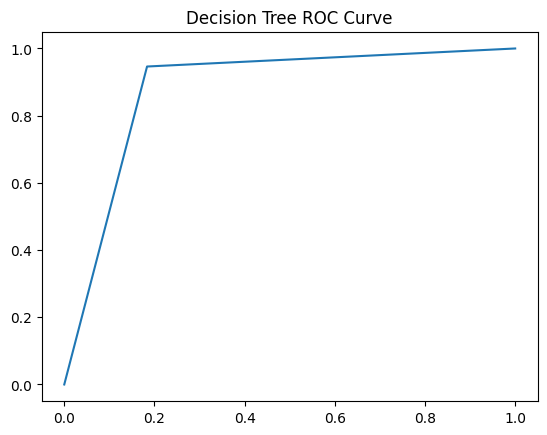

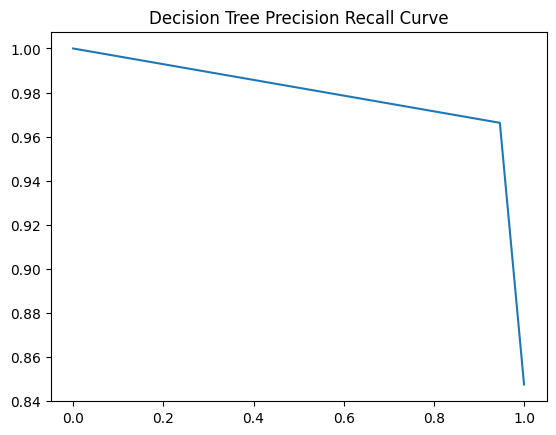

In [12]:
model = DecisionTreeClassifier()

model.fit(X_train,y_train)

pred = model.predict(X_test)

acc_dt = accuracy_score(y_test,pred)

print("Decision Tree Accuracy:",acc_dt)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

prob = model.predict_proba(X_test)[:,1]

fpr_dt,tpr_dt,_ = roc_curve(y_test,prob)

plt.plot(fpr_dt,tpr_dt)
plt.title("Decision Tree ROC Curve")
plt.show()

precision,recall,_ = precision_recall_curve(y_test,prob)

plt.plot(recall,precision)
plt.title("Decision Tree Precision Recall Curve")
plt.show()

Decision Tree Accuracy: 0.928


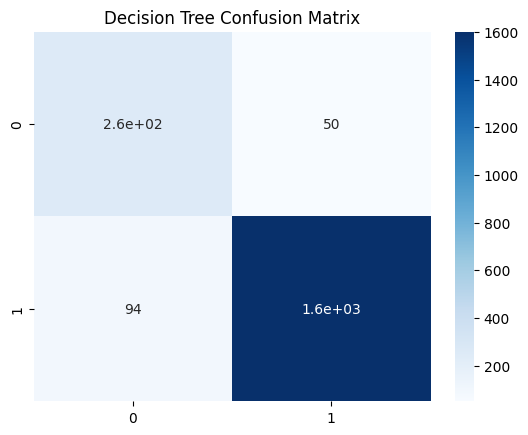

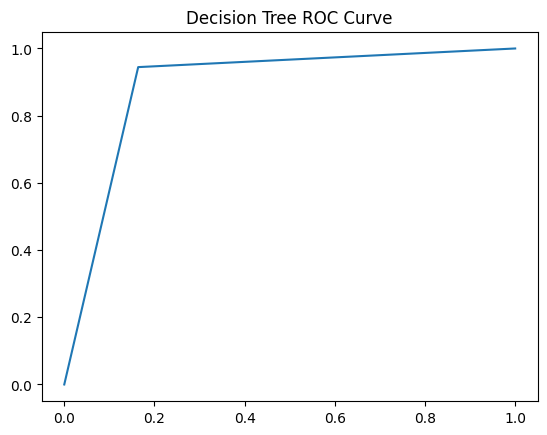

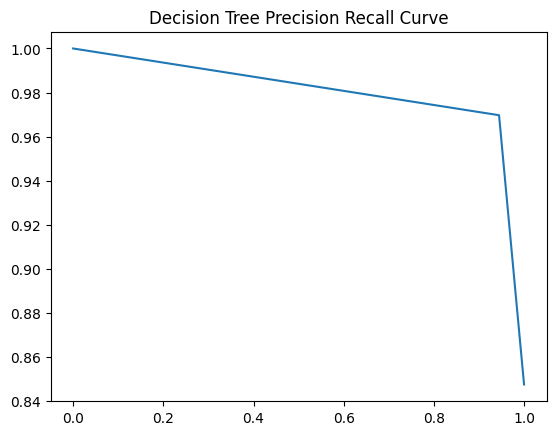

In [13]:
model = DecisionTreeClassifier()

model.fit(X_train,y_train)

pred = model.predict(X_test)

acc_dt = accuracy_score(y_test,pred)

print("Decision Tree Accuracy:",acc_dt)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

prob = model.predict_proba(X_test)[:,1]

fpr_dt,tpr_dt,_ = roc_curve(y_test,prob)

plt.plot(fpr_dt,tpr_dt)
plt.title("Decision Tree ROC Curve")
plt.show()

precision,recall,_ = precision_recall_curve(y_test,prob)

plt.plot(recall,precision)
plt.title("Decision Tree Precision Recall Curve")
plt.show()

AdaBoost Accuracy: 0.939


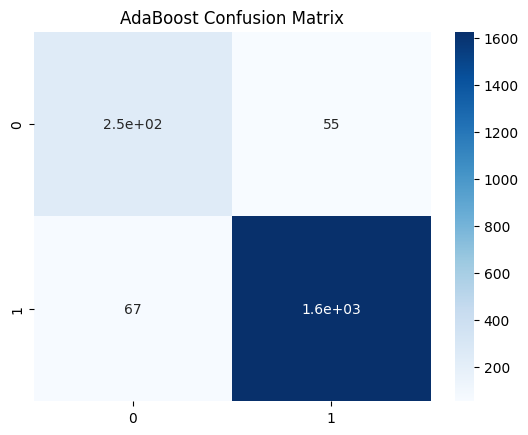

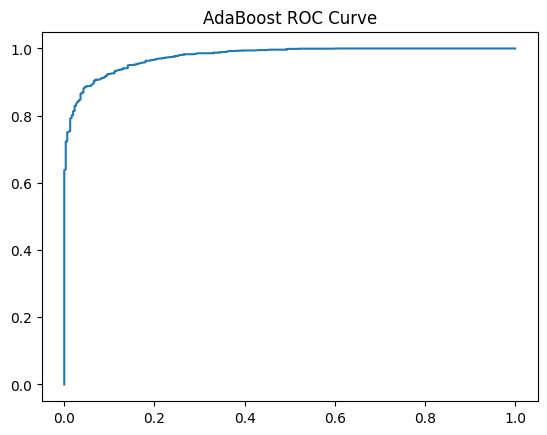

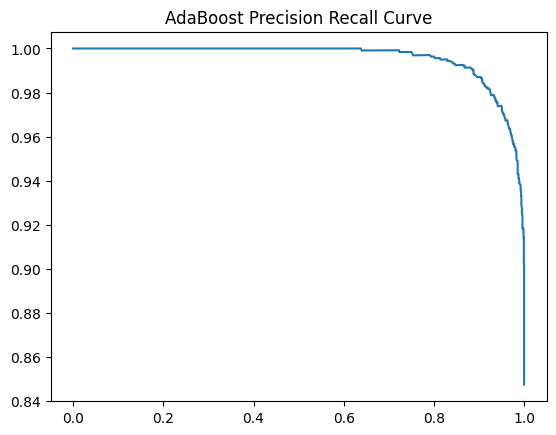

In [14]:
model = AdaBoostClassifier()

model.fit(X_train,y_train)

pred = model.predict(X_test)

acc_adb = accuracy_score(y_test,pred)

print("AdaBoost Accuracy:",acc_adb)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("AdaBoost Confusion Matrix")
plt.show()

prob = model.predict_proba(X_test)[:,1]

fpr_adb,tpr_adb,_ = roc_curve(y_test,prob)

plt.plot(fpr_adb,tpr_adb)
plt.title("AdaBoost ROC Curve")
plt.show()

precision,recall,_ = precision_recall_curve(y_test,prob)

plt.plot(recall,precision)
plt.title("AdaBoost Precision Recall Curve")
plt.show()

Gradient Boosting Accuracy: 0.946


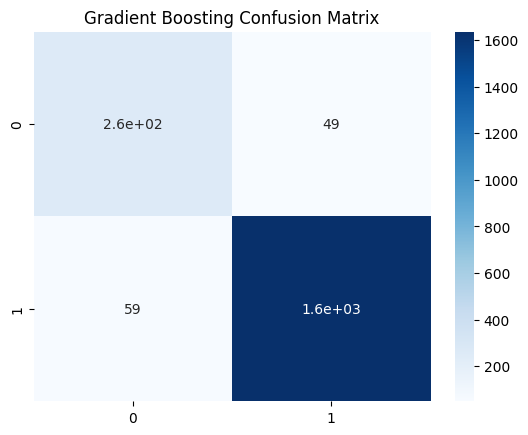

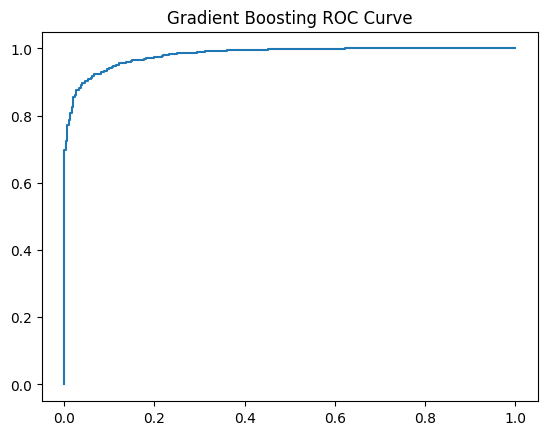

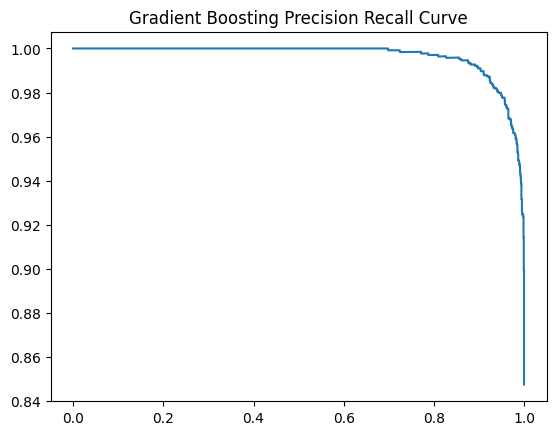

In [15]:
model = GradientBoostingClassifier()

model.fit(X_train,y_train)

pred = model.predict(X_test)

acc_gb = accuracy_score(y_test,pred)

print("Gradient Boosting Accuracy:",acc_gb)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

prob = model.predict_proba(X_test)[:,1]

fpr_gb,tpr_gb,_ = roc_curve(y_test,prob)

plt.plot(fpr_gb,tpr_gb)
plt.title("Gradient Boosting ROC Curve")
plt.show()

precision,recall,_ = precision_recall_curve(y_test,prob)

plt.plot(recall,precision)
plt.title("Gradient Boosting Precision Recall Curve")
plt.show()

Naive Bayes Accuracy: 0.9135


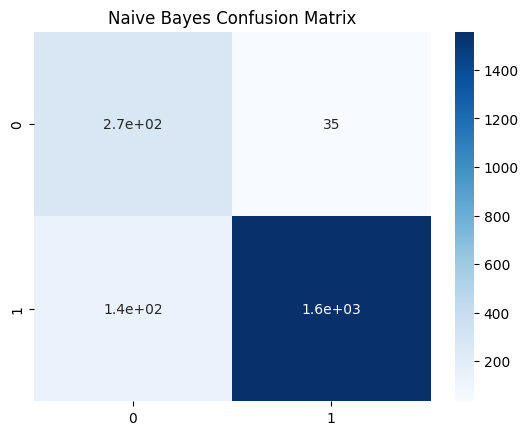

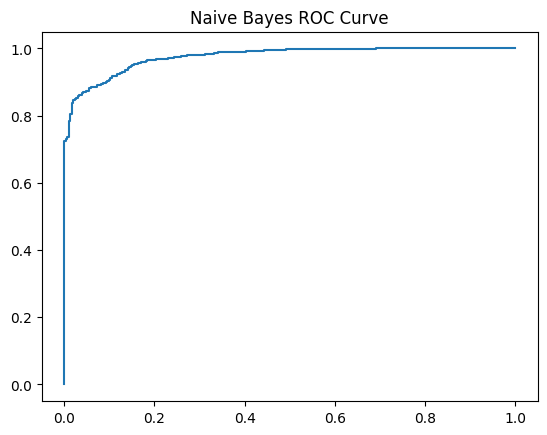

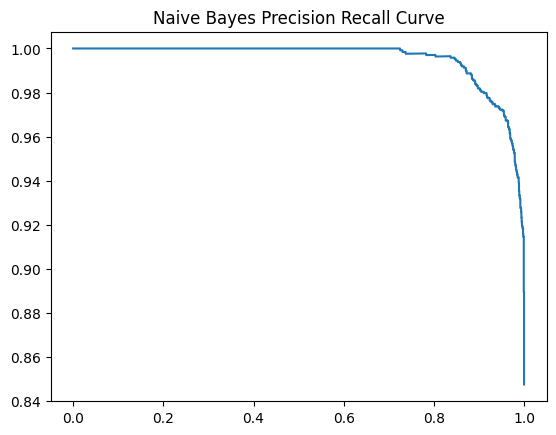

In [16]:
model = GaussianNB()

model.fit(X_train,y_train)

pred = model.predict(X_test)

acc_nb = accuracy_score(y_test,pred)

print("Naive Bayes Accuracy:",acc_nb)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

prob = model.predict_proba(X_test)[:,1]

fpr_nb,tpr_nb,_ = roc_curve(y_test,prob)

plt.plot(fpr_nb,tpr_nb)
plt.title("Naive Bayes ROC Curve")
plt.show()

precision,recall,_ = precision_recall_curve(y_test,prob)

plt.plot(recall,precision)
plt.title("Naive Bayes Precision Recall Curve")
plt.show()

Random Forest Accuracy: 0.944


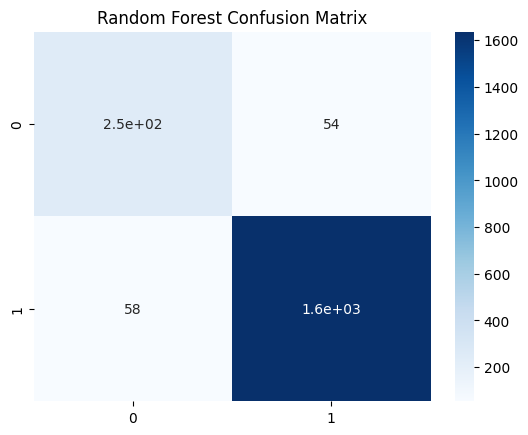

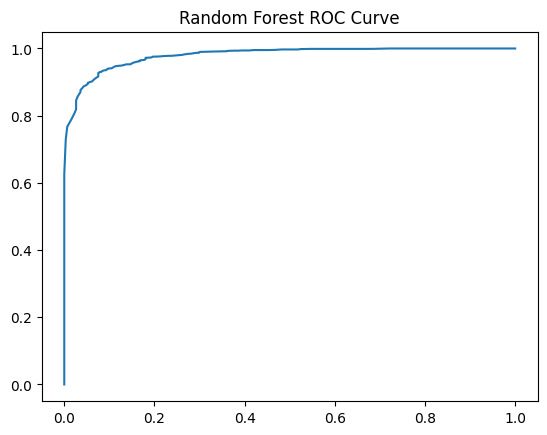

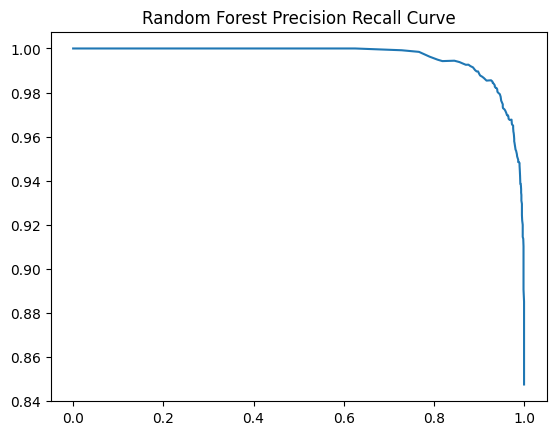

In [17]:
model = RandomForestClassifier()

model.fit(X_train,y_train)

pred = model.predict(X_test)

acc_rf = accuracy_score(y_test,pred)

print("Random Forest Accuracy:",acc_rf)

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

prob = model.predict_proba(X_test)[:,1]

fpr_rf,tpr_rf,_ = roc_curve(y_test,prob)

plt.plot(fpr_rf,tpr_rf)
plt.title("Random Forest ROC Curve")
plt.show()

precision,recall,_ = precision_recall_curve(y_test,prob)

plt.plot(recall,precision)
plt.title("Random Forest Precision Recall Curve")
plt.show()

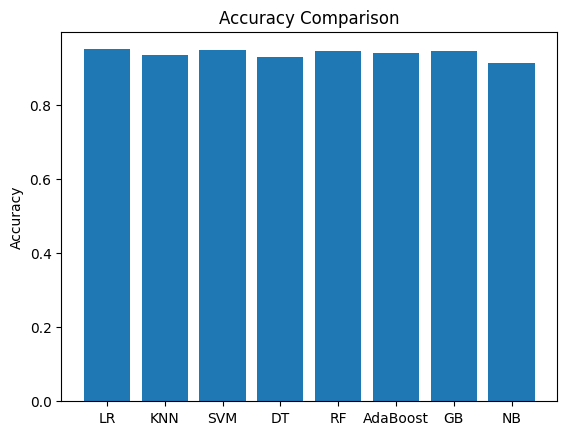

In [18]:
models = ["LR","KNN","SVM","DT","RF","AdaBoost","GB","NB"]

accuracies = [
acc_lr,
acc_knn,
acc_svm,
acc_dt,
acc_rf,
acc_adb,
acc_gb,
acc_nb
]

plt.bar(models,accuracies)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

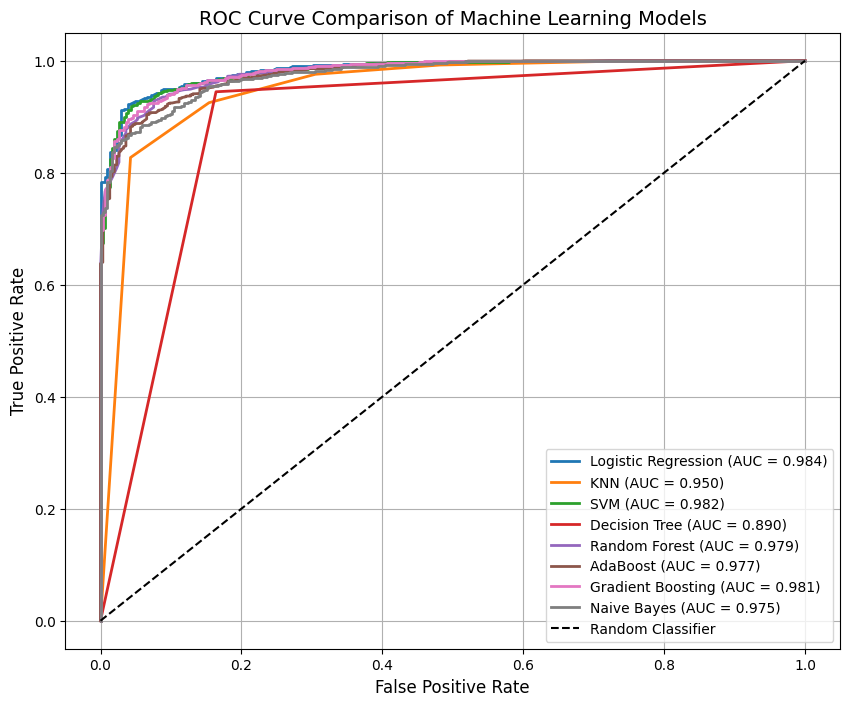

In [19]:
# ==========================================================
# PROFESSIONAL ROC CURVE COMPARISON
# ==========================================================

plt.figure(figsize=(10,8))

plt.plot(fpr_lr,tpr_lr,label="Logistic Regression (AUC = {:.3f})".format(auc(fpr_lr,tpr_lr)),linewidth=2)
plt.plot(fpr_knn,tpr_knn,label="KNN (AUC = {:.3f})".format(auc(fpr_knn,tpr_knn)),linewidth=2)
plt.plot(fpr_svm,tpr_svm,label="SVM (AUC = {:.3f})".format(auc(fpr_svm,tpr_svm)),linewidth=2)
plt.plot(fpr_dt,tpr_dt,label="Decision Tree (AUC = {:.3f})".format(auc(fpr_dt,tpr_dt)),linewidth=2)
plt.plot(fpr_rf,tpr_rf,label="Random Forest (AUC = {:.3f})".format(auc(fpr_rf,tpr_rf)),linewidth=2)
plt.plot(fpr_adb,tpr_adb,label="AdaBoost (AUC = {:.3f})".format(auc(fpr_adb,tpr_adb)),linewidth=2)
plt.plot(fpr_gb,tpr_gb,label="Gradient Boosting (AUC = {:.3f})".format(auc(fpr_gb,tpr_gb)),linewidth=2)
plt.plot(fpr_nb,tpr_nb,label="Naive Bayes (AUC = {:.3f})".format(auc(fpr_nb,tpr_nb)),linewidth=2)

# Random classifier reference line
plt.plot([0,1],[0,1],'k--',label="Random Classifier")

plt.xlabel("False Positive Rate",fontsize=12)
plt.ylabel("True Positive Rate",fontsize=12)

plt.title("ROC Curve Comparison of Machine Learning Models",fontsize=14)

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

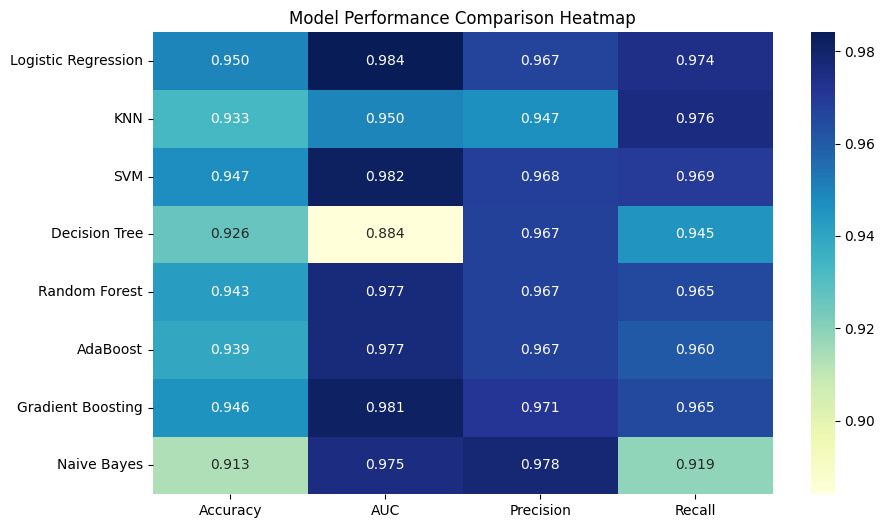

In [20]:
# ==========================================================
# MODEL PERFORMANCE HEATMAP
# ==========================================================

from sklearn.metrics import precision_score, recall_score

performance = []

for name, model in [
("Logistic Regression", LogisticRegression()),
("KNN", KNeighborsClassifier()),
("SVM", SVC(probability=True)),
("Decision Tree", DecisionTreeClassifier()),
("Random Forest", RandomForestClassifier()),
("AdaBoost", AdaBoostClassifier()),
("Gradient Boosting", GradientBoostingClassifier()),
("Naive Bayes", GaussianNB())
]:

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    fpr, tpr, _ = roc_curve(y_test, prob)

    roc_auc = auc(fpr, tpr)

    performance.append([acc, roc_auc, precision, recall])


performance_df = pd.DataFrame(
performance,
columns=["Accuracy","AUC","Precision","Recall"],
index=[
"Logistic Regression",
"KNN",
"SVM",
"Decision Tree",
"Random Forest",
"AdaBoost",
"Gradient Boosting",
"Naive Bayes"
]
)

plt.figure(figsize=(10,6))

sns.heatmap(performance_df,
            annot=True,
            cmap="YlGnBu",
            fmt=".3f")

plt.title("Model Performance Comparison Heatmap")

plt.show()

In [21]:
# ==========================================================
# ACCURACY TABLE OF ALL MODELS
# ==========================================================

accuracy_table = pd.DataFrame({

"Model":[
"Logistic Regression",
"KNN",
"SVM",
"Decision Tree",
"Random Forest",
"AdaBoost",
"Gradient Boosting",
"Naive Bayes"
],

"Accuracy":[
acc_lr,
acc_knn,
acc_svm,
acc_dt,
acc_rf,
acc_adb,
acc_gb,
acc_nb
]

})

accuracy_table = accuracy_table.sort_values(by="Accuracy",ascending=False)

print("Model Accuracy Comparison\n")

print(accuracy_table)

Model Accuracy Comparison

                 Model  Accuracy
0  Logistic Regression    0.9495
2                  SVM    0.9470
6    Gradient Boosting    0.9460
4        Random Forest    0.9440
5             AdaBoost    0.9390
1                  KNN    0.9330
3        Decision Tree    0.9280
7          Naive Bayes    0.9135


In [22]:
best_model = accuracy_table.loc[accuracy_table["Accuracy"].idxmax()]
print("Best Model:")
print(best_model)

Best Model:
Model       Logistic Regression
Accuracy                 0.9495
Name: 0, dtype: object
